TABLE OF CONTENTS

- Imports Necessary Libraries

- Data Exploration
    - Exploring Dataset

- Data Cleaning
    - Missing Data
    - Duplicate Data
    - Detecting Outliers – IQR approach

- Feature Engineering
    - Correlation Analysis
    - Feature Encoding
    - Feature Extraction & Selection

- Model Training, Selection & Evaluation
    - OVERSAMPLING: SMOTE for imbalanced datasets
    - Model Selection
    - Evaluating metrics

- Model Pipeline
    - Save model
    - Load model
    - Test with user's data

---


# Importing the necessary libraries

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# modelling libraries
import pickle
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, average_precision_score, balanced_accuracy_score, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import  XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Data Exploration

In [ ]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
 # to check the summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
# customerID variables don't carry information so we can drop these
df.drop(['customerID'], inplace=True, axis=1)

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Change the label format
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
# to check data balance
df['Churn'].value_counts() # imbalance

,count
Churn,
0,5174
1,1869


<Axes: xlabel='Churn', ylabel='count'>

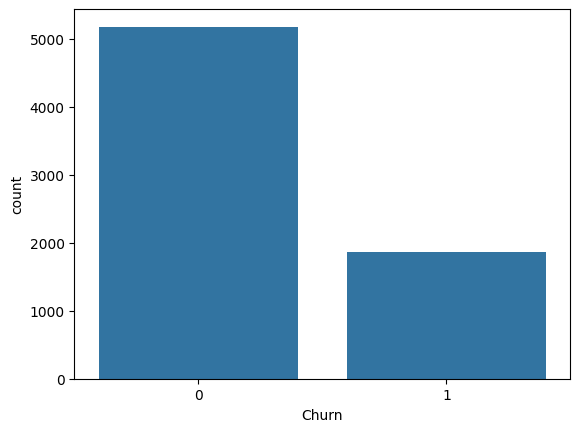

In [ ]:
sns.countplot(data=df, x='Churn')

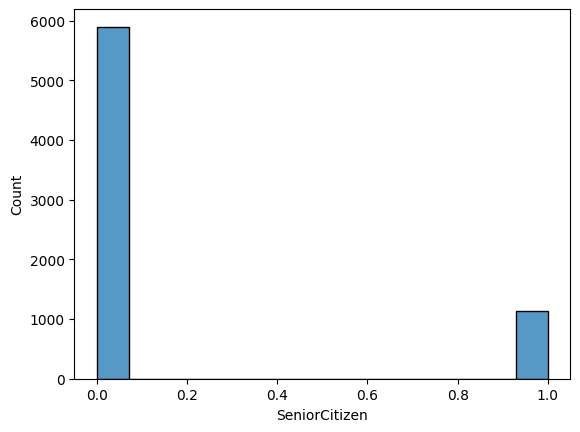

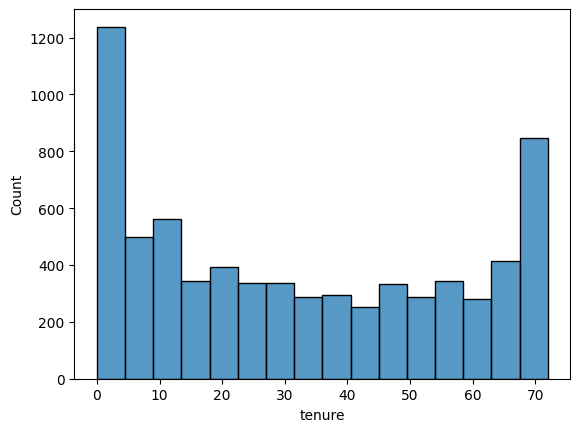

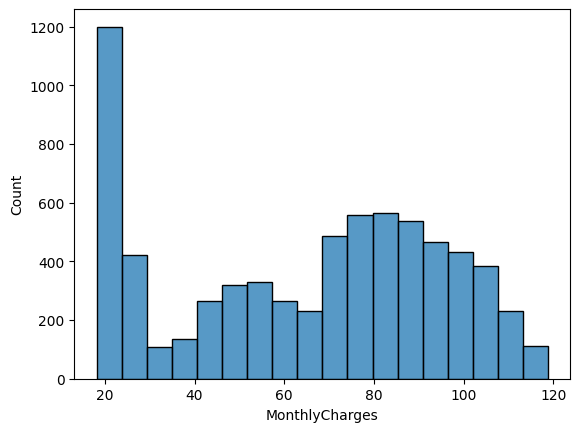

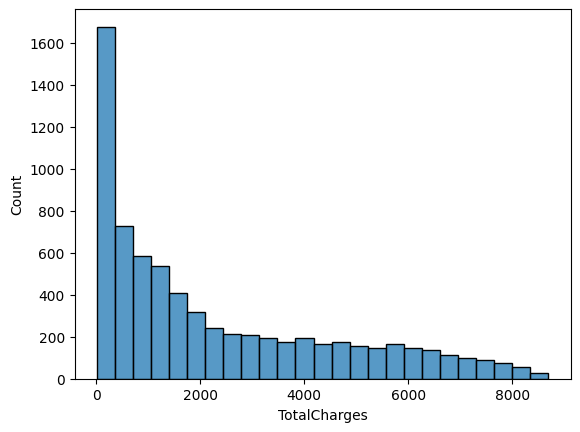

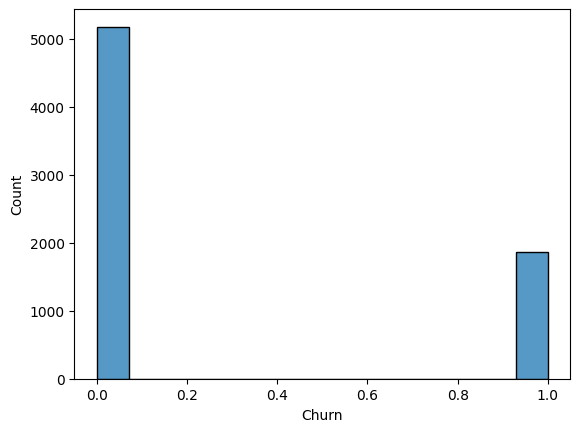

In [ ]:
def hist(col):
    sns.histplot(data=df, x=col)
    plt.show()

numeric_columns = df.select_dtypes(include='number')

for col in numeric_columns:
    hist(col)

  # SeniorCitizen and Churn is discrete (categorical) values

PaymentMethod Vs Churn

In [ ]:
df['PaymentMethod'].value_counts() # Balance

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


In [ ]:
df[['PaymentMethod','Churn']].groupby('PaymentMethod').agg({'Churn':'value_counts'})

Churn
PaymentMethod             Churn       
Bank transfer (automatic) 0       1286
                          1        258
Credit card (automatic)   0       1290
                          1        232
Electronic check          0       1294
                          1       1071
Mailed check              0       1304
                          1        308

Contract Vs Churn

In [ ]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


Text(0, 0.5, '')

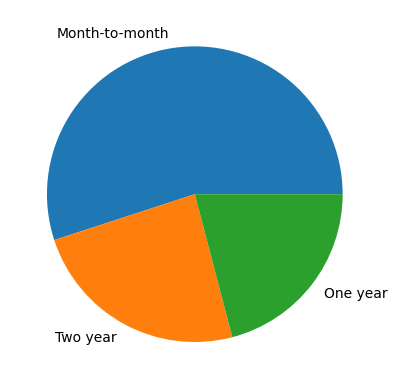

In [ ]:
# Visualizing the distribution of 'Contract' variable in the dataset

df['Contract'].value_counts().plot.pie()
plt.ylabel('')

In [ ]:
# Check the distribution of churn by contract
df[['Contract','Churn']].groupby('Contract').agg({'Churn':'value_counts'})

Churn
Contract       Churn       
Month-to-month 0       2220
               1       1655
One year       0       1307
               1        166
Two year       0       1647
               1         48

In [ ]:
# Check the distribution of Churn by Online Security variable
df[['OnlineSecurity','Churn']].groupby('OnlineSecurity').agg({'Churn':'mean'}).round(2)

,Churn
OnlineSecurity,
No,0.42
No internet service,0.07
Yes,0.15


In [ ]:
df['OnlineSecurity'].value_counts()

# Could make 'No internet service' to 'No' to reduce model complexity

,count
OnlineSecurity,
No,3498
Yes,2019
No internet service,1526


Demographic Vs Churn

In [ ]:
df[['Partner','Churn']].groupby('Partner').agg({'Churn':'value_counts'})

Churn
Partner Churn       
No      0       2441
        1       1200
Yes     0       2733
        1        669

# Data Cleaning

Duplicate Data


In [ ]:
df.duplicated().sum()

np.int64(22)

In [ ]:
# Remove duplicated data
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

Missing Data

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


Detecting Outliers

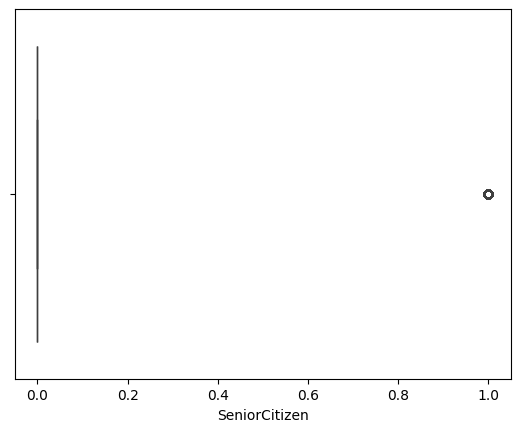

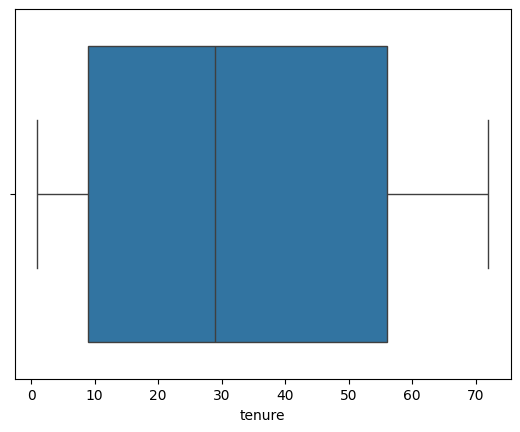

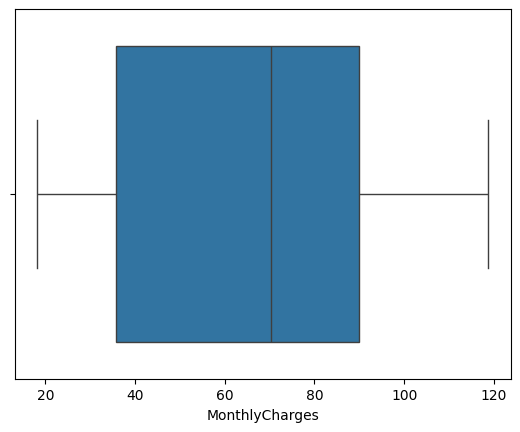

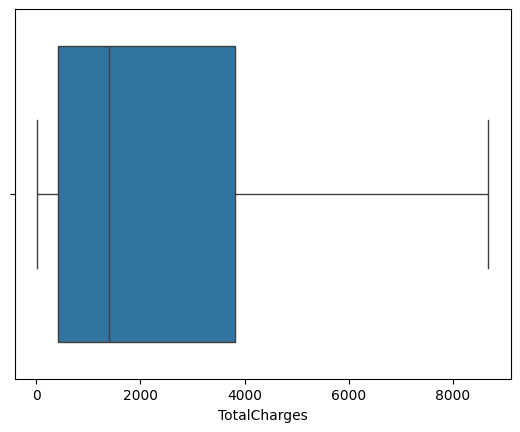

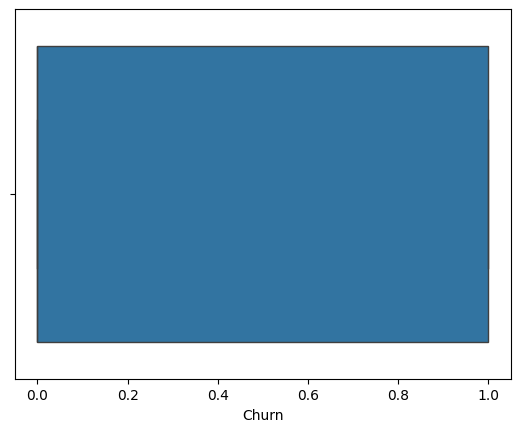

In [ ]:
def box_plot(col):
    sns.boxplot(data=df, x=col)
    plt.show()

numeric_columns = df.select_dtypes(include='number')

for col in numeric_columns:
    box_plot(col)

In [ ]:
# def detect_outliers(col_name):
#   df_col_name = df[col_name]

#   # to define upper and lower outlier boundaries by third and first quartiles
#   Q1 = df_col_name.quantile(0.25)
#   Q3 = df_col_name.quantile(0.75)
#   IQR = Q3-Q1
#   lower_bound = Q1 - 1.5*IQR
#   upper_bound = Q3 + 1.5*IQR

#   outliers = (df_col_name < lower_bound) | (df_col_name > upper_bound)
#   outliers_index = df_col_name[outliers].index

#   print(f"{col_name} variable\n"
#         f"Outliers boundaries: {lower_bound}, {upper_bound}\n"
#         f"Number of outliers : {len(outliers_index)}")

#   return col_name, lower_bound, upper_bound, outliers_index

# Feature Engineering

## Correlation Analysis

In [ ]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.014456,0.219131,0.101642,0.151270
tenure,0.014456,1.000000,0.244194,0.825293,-0.353339
MonthlyCharges,0.219131,0.244194,1.000000,0.650540,0.194008
TotalCharges,0.101642,0.825293,0.650540,1.000000,-0.198362
Churn,0.151270,-0.353339,0.194008,-0.198362,1.000000


In [ ]:
df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
MonthlyCharges,0.194008
SeniorCitizen,0.151270
TotalCharges,-0.198362
tenure,-0.353339


In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Feature Extraction

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<Axes: xlabel='tenure', ylabel='Count'>

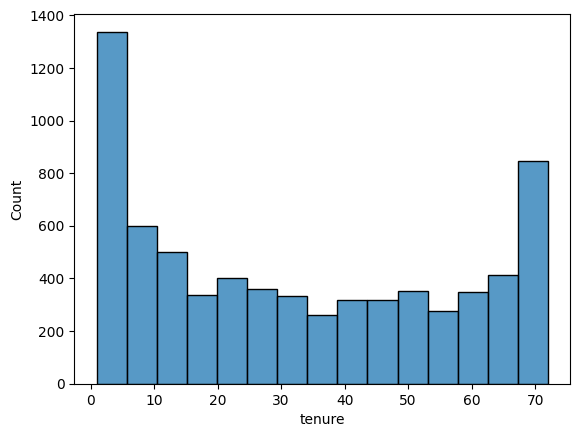

In [ ]:
sns.histplot(df['tenure'])

In [ ]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-6yr"]
)

# Encode ordinally
df['tenure_group'] = df['tenure_group'].map({
    '0-1yr':0,
    '1-2yr':1,
    '2-4yr':2,
    '4-6yr':3
})

In [ ]:
df['tenure_group'] = df['tenure_group'].astype(int)

In [ ]:
# Create montly charge ratio
df['charge_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

In [ ]:
# total charge per month within customer duration

df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

In [ ]:
# Number of services
services = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['num_services'] = (df[services] == 1).sum(axis=1)

In [ ]:
# Correlation analysis
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,tenure_group,charge_per_tenure,avg_monthly_spend,num_services
SeniorCitizen,1.000000,0.014456,0.219131,0.101642,0.151270,0.022126,0.050146,0.200776,NaN
tenure,0.014456,1.000000,0.244194,0.825293,-0.353339,0.960935,-0.599472,0.409022,NaN
MonthlyCharges,0.219131,0.244194,1.000000,0.650540,0.194008,0.234589,0.102985,0.957552,NaN
TotalCharges,0.101642,0.825293,0.650540,1.000000,-0.198362,0.781974,-0.428302,0.763794,NaN
Churn,0.151270,-0.353339,0.194008,-0.198362,1.000000,-0.346394,0.421269,0.073244,NaN
tenure_group,0.022126,0.960935,0.234589,0.781974,-0.346394,1.000000,-0.614504,0.403277,NaN
charge_per_tenure,0.050146,-0.599472,0.102985,-0.428302,0.421269,-0.614504,1.000000,-0.178392,NaN
avg_monthly_spend,0.200776,0.409022,0.957552,0.763794,0.073244,0.403277,-0.178392,1.000000,NaN
num_services,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,charge_per_tenure,avg_monthly_spend,num_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,14.925000,14.925000,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2,1.627143,53.985714,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0,17.950000,36.050000,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2,0.919565,40.016304,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0,23.566667,50.550000,0


# Encoding

Split numeric and categorical cols

In [ ]:
categorical=list(df.select_dtypes(include=['object', 'category']).columns)
numerical=list(df.select_dtypes(include=['number']).columns)

In [ ]:
categorical

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [ ]:
# unique values of all categorical col

for i in categorical:
  print(f"{i.upper()}\n{df[i].value_counts()}\n")

GENDER
gender
Male      3535
Female    3475
Name: count, dtype: int64

PARTNER
Partner
No     3617
Yes    3393
Name: count, dtype: int64

DEPENDENTS
Dependents
No     4911
Yes    2099
Name: count, dtype: int64

PHONESERVICE
PhoneService
Yes    6330
No      680
Name: count, dtype: int64

MULTIPLELINES
MultipleLines
No                  3363
Yes                 2967
No phone service     680
Name: count, dtype: int64

INTERNETSERVICE
InternetService
Fiber optic    3090
DSL            2414
No             1506
Name: count, dtype: int64

ONLINESECURITY
OnlineSecurity
No                     3489
Yes                    2015
No internet service    1506
Name: count, dtype: int64

ONLINEBACKUP
OnlineBackup
No                     3079
Yes                    2425
No internet service    1506
Name: count, dtype: int64

DEVICEPROTECTION
DeviceProtection
No                     3086
Yes                    2418
No internet service    1506
Name: count, dtype: int64

TECHSUPPORT
TechSupport
No              

In [ ]:
# No internet service & No phone service --> No

service_cols = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for col in service_cols:
    df[col] = df[col].replace({
        'No internet service':'No',
        'No phone service':'No'
    })

In [ ]:
numerical

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'tenure_group',
 'charge_per_tenure',
 'avg_monthly_spend',
 'num_services']

In [ ]:
numerical.remove('Churn')

In [ ]:
numerical.remove('SeniorCitizen')

Binary Columns (Yes / No) - Label Encoding

In [ ]:
binary_cols = [
'Partner','Dependents','PhoneService','PaperlessBilling',
'MultipleLines','OnlineSecurity','OnlineBackup',
'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes':1,'No':0})

Gender - Binary Encoding

In [ ]:
df['gender'] = df['gender'].map({'Male':1,'Female':0})

Contract - Ordinal Encoding

In [ ]:
df['Contract'] = df['Contract'].map({
    'Month-to-month':0,
    'One year':1,
    'Two year':2
})

In [ ]:
final_df = df.copy()
final_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,charge_per_tenure,avg_monthly_spend,num_services
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,0,1,Electronic check,29.85,29.85,0,0,14.925000,14.925000,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,1,0,Mailed check,56.95,1889.50,0,2,1.627143,53.985714,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,0,1,Mailed check,53.85,108.15,1,0,17.950000,36.050000,0
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,1,0,Bank transfer (automatic),42.30,1840.75,0,2,0.919565,40.016304,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,0,1,Electronic check,70.70,151.65,1,0,23.566667,50.550000,0


# InternetService & PaymentMethod - One-Hot Encoding

In [ ]:
df = pd.get_dummies(df, columns=['PaymentMethod'], drop_first=True)

In [ ]:
df = pd.get_dummies(df, columns=['InternetService'], drop_first=True)

## Feature Importance

Generating new more important features

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

X_train.shape, y_train.shape

((5257, 26), (5257,))

SMOTE for imblanced data

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check new distribution
print("Original class distribution:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_res).value_counts())

Original class distribution:
 Churn
0    3864
1    1393
Name: count, dtype: int64

After SMOTE:
 Churn
0    3864
1    3864
Name: count, dtype: int64


In [ ]:
# We'll train a model to identify the importance of features
rf_model = RandomForestClassifier(class_weight='balanced').fit(X_train_res, y_train_res)
predicted_values = rf_model.predict(X_test)
print('--Confusion Matrix--')
cof_matrix = confusion_matrix(y_test, predicted_values)
print(cof_matrix)

print('\n')
print("Precision : ", precision_score(y_test, predicted_values))
print("Recall : ", recall_score(y_test, predicted_values))
print("F1 Score : ", f1_score(y_test, predicted_values))
print("Accuracy : ", accuracy_score(y_test, predicted_values))

--Confusion Matrix--
[[1083  206]
 [ 180  284]]


Precision :  0.5795918367346938
Recall :  0.6120689655172413
F1 Score :  0.5953878406708596
Accuracy :  0.7798060467769538


ROC-AUC: 0.8230894371472137


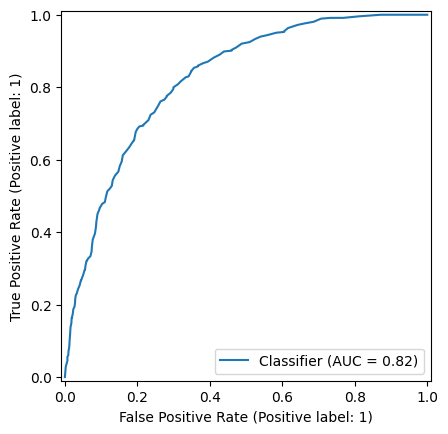

In [ ]:
# ROC-AUC
y_prob = rf_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)
RocCurveDisplay.from_predictions(y_test, y_prob)

In [ ]:
rf_model.feature_importances_

array([0.01782518, 0.01044553, 0.0175991 , 0.02139361, 0.07528309,
       0.01036658, 0.01122588, 0.02921599, 0.01742832, 0.01379529,
       0.03428954, 0.010117  , 0.00980203, 0.10490793, 0.0146055 ,
       0.09466927, 0.09205239, 0.02164808, 0.13957881, 0.08736884,
       0.        , 0.01298047, 0.09181195, 0.01208972, 0.03820855,
       0.01129134])

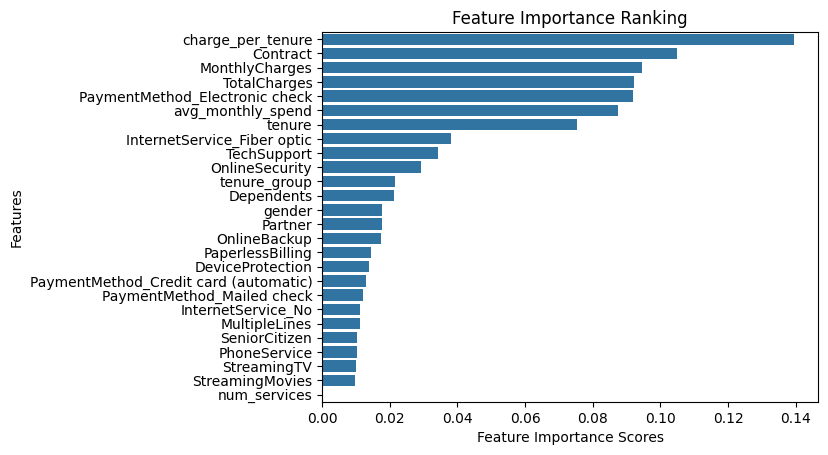

In [ ]:
# to check feature importances
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.xlabel('Feature Importance Scores')
plt.ylabel('Features')
plt.title("Feature Importance Ranking")
plt.show()

Some columns has lowest feature importance. So we will drop it while training or



try to create more effective columns than those with less important columns.

---

# Model Training, Selection & Evaluation

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, y_train.shape

((5608, 26), (5608,))

OVERSAMPLING: SMOTE for imbalanced datasets

In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

Scaling: Standardization (Optional)

- Ensemble models normally do not require scaling.

In [ ]:
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_resampled)
# X_test_scaled = scaler.transform(X_test)

In [ ]:
X_resampled.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
OnlineSecurity,int64
OnlineBackup,int64
DeviceProtection,int64


In [ ]:
models = [RandomForestClassifier(class_weight='balanced'),
          XGBClassifier(class_weight='balanced'),
          LGBMClassifier(class_weight='balanced')]
for model in models:
    print(f'Model name : {model}')
    model.fit(X_resampled, y_resampled)
    predicted_values = model.predict(X_test)

    print('--Confusion Matrix--')
    cof_matrix = confusion_matrix(y_test, predicted_values)
    print(cof_matrix)
    print("Precision : ", precision_score(y_test, predicted_values))
    print("Recall : ", recall_score(y_test, predicted_values))
    print("F1 Score : ", f1_score(y_test, predicted_values))
    print("Accuracy : ", accuracy_score(y_test, predicted_values))
    print('\n')

Model name : RandomForestClassifier(class_weight='balanced')
--Confusion Matrix--
[[886 145]
 [150 221]]
Precision :  0.6038251366120219
Recall :  0.5956873315363881
F1 Score :  0.5997286295793759
Accuracy :  0.7895863052781741


Model name : XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:33:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--Confusion Matrix--
[[883 148]
 [168 203]]
Precision :  0.5783475783475783
Recall :  0.5471698113207547
F1 Score :  0.5623268698060941
Accuracy :  0.7746077032810271


Model name : LGBMClassifier(class_weight='balanced')
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4122, number of negative: 4122
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002998 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1145
[LightGBM] [Info] Number of data points in the train set: 8244, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
--Confusion Matrix--
[[866 165]
 [153 218]]
Precision :  0.5691906005221932
Recall :  0.5876010781671159
F1 Score :  0.5782493368700266
Accuracy :  0.7731811697574893




In [ ]:
skf = StratifiedKFold(n_splits=5)

models = [
    RandomForestClassifier(class_weight='balanced', random_state=42),
    XGBClassifier(scale_pos_weight=(len(y_resampled[y_resampled==0]) /
                                    len(y_resampled[y_resampled==1])),
                  eval_metric='logloss',
                  random_state=42),
    LGBMClassifier(class_weight='balanced', random_state=42)
]

for model in models:

    print(f'\n====== {model.__class__.__name__} ======')

    model.fit(X_resampled, y_resampled)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob > 0.35).astype(int)

    print('-- Confusion Matrix --')
    print(confusion_matrix(y_test, y_pred))

    print("Precision :", precision_score(y_test, y_pred))
    print("Recall :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))

    print("ROC AUC :", roc_auc_score(y_test, y_prob))
    print("PR AUC :", average_precision_score(y_test, y_prob))

    print("\n-- Classification Report --")
    print(classification_report(y_test, y_pred))


====== RandomForestClassifier ======
-- Confusion Matrix --
[[765 266]
 [ 95 276]]
Precision : 0.5092250922509225
Recall : 0.7439353099730458
F1 Score : 0.6046002190580504
Accuracy : 0.7425106990014265
Balanced Accuracy : 0.7429666850544181
ROC AUC : 0.8176501499342486
PR AUC : 0.5747403682840011

-- Classification Report --
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1031
           1       0.51      0.74      0.60       371

    accuracy                           0.74      1402
   macro avg       0.70      0.74      0.71      1402
weighted avg       0.79      0.74      0.75      1402

F1 CV Score: 0.8339040483776005

====== XGBClassifier ======
-- Confusion Matrix --
[[805 226]
 [122 249]]
Precision : 0.5242105263157895
Recall : 0.6711590296495957
F1 Score : 0.5886524822695035
Accuracy : 0.7517831669044223
Balanced Accuracy : 0.7259771869877465
ROC AUC : 0.8110933043312305
PR AUC : 0.5876997716447172

-- Classification Repo

---
The best result is with RandomForst because it has better auc and cross val score than other model.

But it is not optimal and need tuning (usually boosting models require tuning)

---

**Hyperparameter Tuning**

#### Tune Random Forest

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    rf_params,
    n_iter=30,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

rf_search.fit(X_resampled, y_resampled)

print("Best RF Params:", rf_search.best_params_)

Best RF Params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}


#### Tune XGBoost

In [ ]:
xgb_params = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
    "gamma": [0, 1, 5]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
        eval_metric="logloss",
        random_state=42
    ),
    xgb_params,
    n_iter=30,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

xgb_search.fit(X_resampled, y_resampled)

print("Best XGB Params:", xgb_search.best_params_)

Best XGB Params: {'subsample': 1.0, 'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.7}


#### Tune LightGBM

In [ ]:
lgbm_params = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 10, 20],
    "min_child_samples": [20, 40, 60],
    "subsample": [0.7, 0.9, 1.0]
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(class_weight="balanced", random_state=42),
    lgbm_params,
    n_iter=30,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

lgbm_search.fit(X_resampled, y_resampled)

print("Best LGBM Params:", lgbm_search.best_params_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4122, number of negative: 4122
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1145
[LightGBM] [Info] Number of data points in the train set: 8244, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best LGBM Params: {'subsample': 0.7, 'num_leaves': 63, 'n_estimators': 400, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.01}


In [ ]:
best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_
best_lgbm = lgbm_search.best_estimator_

In [ ]:
best_models = [best_rf, best_xgb, best_lgbm]

results = []

for model in best_models:

    name = model.__class__.__name__

    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob > 0.35).astype(int)   # your tuned threshold

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    results.append([name, precision, recall, f1, acc, bal_acc, roc_auc, pr_auc])

    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))


RandomForestClassifier
[[752 279]
 [ 85 286]]

XGBClassifier
[[724 307]
 [ 69 302]]

LGBMClassifier
[[774 257]
 [ 87 284]]


In [ ]:
import pandas as pd

columns = ["Model","Precision","Recall","F1","Accuracy",
           "Balanced Accuracy","ROC-AUC","PR-AUC"]

results_df = pd.DataFrame(results, columns=columns)

results_df

,Model,Precision,Recall,F1,Accuracy,Balanced Accuracy,ROC-AUC,PR-AUC
0,RandomForestClassifier,0.506195,0.770889,0.611111,0.740371,0.750139,0.833355,0.610209
1,XGBClassifier,0.495895,0.814016,0.616327,0.731812,0.758124,0.828160,0.607421
2,LGBMClassifier,0.524954,0.765499,0.622807,0.754636,0.758113,0.834321,0.620439


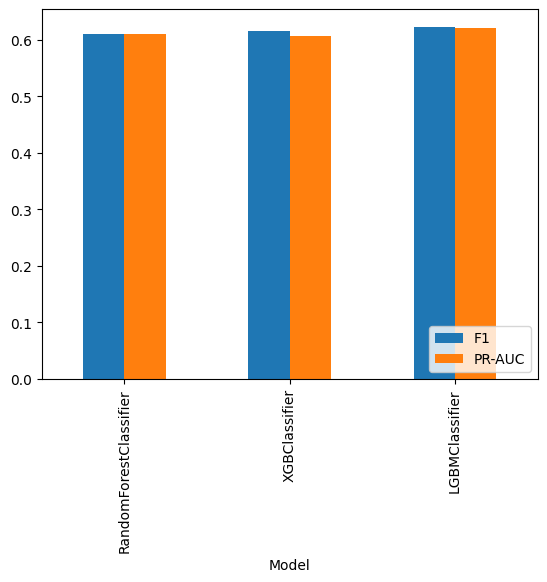

In [ ]:
results_df.set_index("Model")[["F1","PR-AUC"]].plot(kind="bar")
plt.legend(loc='lower right')

Overall, the best model is LightGBM with Highest F1 score, Highest precision, ROC-AUC, PR-AUC, accuracy.

This means LightGBM has the best overall balance.

# Model Pipeline

In [ ]:
# Column Transformers

numeric_features = ['tenure_group', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
                    'charge_per_tenure', 'avg_monthly_spend', 'num_services']

binary_cats = ['gender', 'Partner', 'PaperlessBilling',
'Dependents', 'PhoneService','PaperlessBilling', 'MultipleLines',
'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

mul_cats = ['InternetService', 'PaymentMethod']

ord_cats = ['Contract']
# Contract order
contract_order = ['Month-to-month', 'One year', 'Two year']

preprocessor = ColumnTransformer([
    ("num", 'passthrough', numeric_features),          # just keep numeric features
    ("binary", 'passthrough', binary_cats),           # already 0/1
    ("multiple", OneHotEncoder(handle_unknown='ignore'), mul_cats),
    ("ordinal", 'passthrough', ord_cats) # already order
])

In [ ]:
# Pipeline

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LGBMClassifier(
        n_estimators=400,
        learning_rate=0.01,
        num_leaves=63,
        max_depth=10,
        min_child_samples=20,
        subsample=0.7,
        class_weight="balanced",
        random_state=42
    ))
])

In [ ]:
# New final train test split

X = final_df.drop('Churn', axis=1)
y = final_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, y_train.shape

((5608, 23), (5608,))

In [ ]:
final_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 4122, number of negative: 4122
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002892 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6525
[LightGBM] [Info] Number of data points in the train set: 8244, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['tenure_group',
                                                   'SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'charge_per_tenure',
                                                   'avg_monthly_spend',
                                                   'num_services']),
                                                 ('binary', 'passthrough',
                                                  ['gender', 'Partner',
                                                   'PaperlessBilling',
                                                   'Dependents', 'PhoneService',
                                                   'PaperlessBilling',
                                                   'MultipleLines',
                                                   'OnlineSe...
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies']),
                                                 ('multiple',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['InternetService',
                                                   'PaymentMethod']),
                                                 ('ordinal', 'passthrough',
                                                  ['Contract'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LGBMClassifier(class_weight='balanced', learning_rate=0.01,
                                max_depth=10, n_estimators=400, num_leaves=63,
                                random_state=42, subsample=0.7))])

In [ ]:
y_prob = final_pipeline.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.35).astype(int)   # tuned threshold

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score

print("-- Confusion Matrix --")
print(confusion_matrix(y_test, y_pred))
print("\n-- Classification Report --")
print(classification_report(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

-- Confusion Matrix --
[[815 216]
 [110 261]]

-- Classification Report --
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1031
           1       0.55      0.70      0.62       371

    accuracy                           0.77      1402
   macro avg       0.71      0.75      0.72      1402
weighted avg       0.79      0.77      0.78      1402

F1 Score: 0.6155660377358491
Balanced Accuracy: 0.7469993542500543
ROC-AUC: 0.8357795143019233
PR-AUC: 0.6299653555118186


In [ ]:
import joblib

joblib.dump(final_pipeline, "final_tuned_lgbm_pipeline.pkl")

['final_tuned_lgbm_pipeline.pkl']

### Load model

In [ ]:
# Load model
loaded_model = joblib.load("final_tuned_lgbm_pipeline.pkl")

# Predict
y_pred = loaded_model.predict(X_test)

if y_pred[0] == 1:
    print('Customer will churn.')
else:
    print('Customer will not churn.')


Customer will not churn.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Test with User's Data

In [ ]:
final_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,charge_per_tenure,avg_monthly_spend,num_services
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,0,1,Electronic check,29.85,29.85,0,0,14.925000,14.925000,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,1,0,Mailed check,56.95,1889.50,0,2,1.627143,53.985714,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,0,1,Mailed check,53.85,108.15,1,0,17.950000,36.050000,0
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,1,0,Bank transfer (automatic),42.30,1840.75,0,2,0.919565,40.016304,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,0,1,Electronic check,70.70,151.65,1,0,23.566667,50.550000,0


In [ ]:
import pandas as pd

# Ask user for input
print("Please enter the following user information:")

# Numeric
SeniorCitizen = int(input("SeniorCitizen (0=No, 1=Yes): "))
tenure = int(input("Tenure (months): "))
MonthlyCharges = float(input("MonthlyCharges: "))
TotalCharges = float(input("TotalCharges: "))
charge_per_tenure = float(input("Charge per tenure: "))
avg_monthly_spend = float(input("Average monthly spend: "))
num_services = int(input("Number of services: "))

# Binary (0/1)
gender = int(input("Gender (Male=1, Female=0): "))
Partner = int(input("Has Partner? (0=No, 1=Yes): "))
Dependents = int(input("Has Dependents? (0=No, 1=Yes): "))
PhoneService = int(input("PhoneService (0=No, 1=Yes): "))
MultipleLines = int(input("MultipleLines (0=No, 1=Yes): "))
OnlineSecurity = int(input("OnlineSecurity (0=No, 1=Yes): "))
OnlineBackup = int(input("OnlineBackup (0=No, 1=Yes): "))
DeviceProtection = int(input("DeviceProtection (0=No, 1=Yes): "))
TechSupport = int(input("TechSupport (0=No, 1=Yes): "))
StreamingTV = int(input("StreamingTV (0=No, 1=Yes): "))
StreamingMovies = int(input("StreamingMovies (0=No, 1=Yes): "))
PaperlessBilling = int(input("PaperlessBilling (0=No, 1=Yes): "))

# Multiple-category (OneHot)
InternetService = input("InternetService (DSL/Fiber optic/No): ")
PaymentMethod = input("PaymentMethod (Electronic check/Mailed check/Credit card (automatic)/Bank transfer): ")

# Ordinal
Contract = input("Contract (0=Month-to-month/1=One year/2=Two year): ")
tenure_group = input("Tenure group (0='0-1yr', 1='1-2yr', 2='2-4yr', 3='4-6yr'): ")

# Create DataFrame in correct order
user_data = pd.DataFrame([{
    'SeniorCitizen': SeniorCitizen,
    'tenure': tenure,
    'MonthlyCharges': MonthlyCharges,
    'TotalCharges': TotalCharges,
    'charge_per_tenure': charge_per_tenure,
    'avg_monthly_spend': avg_monthly_spend,
    'num_services': num_services,
    'gender': gender,
    'Partner': Partner,
    'Dependents': Dependents,
    'PhoneService': PhoneService,
    'MultipleLines': MultipleLines,
    'OnlineSecurity': OnlineSecurity,
    'OnlineBackup': OnlineBackup,
    'DeviceProtection': DeviceProtection,
    'TechSupport': TechSupport,
    'StreamingTV': StreamingTV,
    'StreamingMovies': StreamingMovies,
    'PaperlessBilling': PaperlessBilling,
    'InternetService': InternetService,
    'PaymentMethod': PaymentMethod,
    'Contract': Contract,
    'tenure_group': tenure_group
}])

print("\nUser Data Collected:\n", user_data)

Please enter the following user information:
SeniorCitizen (0=No, 1=Yes): 0
Tenure (months): 3
MonthlyCharges: 22
TotalCharges: 55
Charge per tenure: 3
Average monthly spend: 11
Number of services: 3
Gender (Male=1, Female=0): 0
Has Partner? (0=No, 1=Yes): 0
Has Dependents? (0=No, 1=Yes): 0
PhoneService (0=No, 1=Yes): 0
MultipleLines (0=No, 1=Yes): 0
OnlineSecurity (0=No, 1=Yes): 0
OnlineBackup (0=No, 1=Yes): 0
DeviceProtection (0=No, 1=Yes): 0
TechSupport (0=No, 1=Yes): 0
StreamingTV (0=No, 1=Yes): 0
StreamingMovies (0=No, 1=Yes): 0
PaperlessBilling (0=No, 1=Yes): 0
InternetService (DSL/Fiber optic/No): DSL
PaymentMethod (Electronic check/Mailed check/Credit card (automatic)/Bank transfer): Electronic check
Contract (0=Month-to-month/1=One year/2=Two year): 0
Tenure group (0='0-1yr', 1='1-2yr', 2='2-4yr', 3='4-6yr'): 0

User Data Collected:
    SeniorCitizen  tenure  ...  Contract  tenure_group
0              0       3  ...         0             0

[1 rows x 23 columns]


In [ ]:
# Predicted class
print(f"Predicted Class:  {y_pred[0]}\n")

if y_pred[0] == 1:
    print("⚠️ This user is likely to churn.")
else:
    print("✅ This user is likely safe.")

Predicted Class:  1

⚠️ This user is likely to churn.
